# Correlation between subcellular regions

The `rc` (region correlation) module provides metrics to assess how well subcellular regions (e.g. cell and nucleus) align. 

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spatialdata as sd
import spatialdata_plot  # noqa
from pathlib import Path
import segtraq
import matplotlib.patches as patches
import matplotlib.pyplot as plt
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")
sdata = sd.read_zarr(data_path / "proseg_output_v3/sdata_proseg_crop.zarr")
#sdata_ws = sd.read_zarr("../../data/bidcell.zarr")

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__vers

The SpatialData object is subset for better visualization.

In [3]:
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


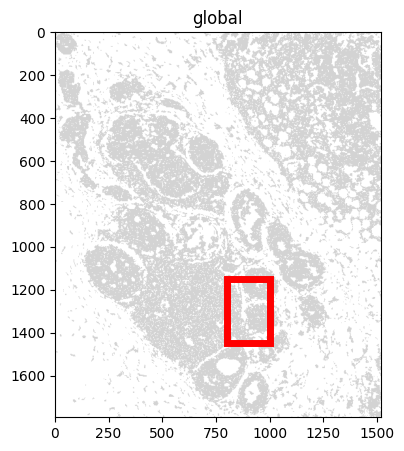

In [ ]:
f, ax = plt.subplots(figsize=(5, 5))
sdata_ws.pl.render_shapes("cell_boundaries").pl.show(ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

In [5]:
sdata = sdata_ws.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


Next, the `SegTraQ` object is initialized.

In [3]:
#st = segtraq.SegTraQ(sdata, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid")
st = segtraq.SegTraQ(
    sdata,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_volume_key="volume",
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

The `spatialdata`dataset contains cell and nuclear masks as `Shapes`and `Labels`, as shown below.

## Intersection over Union between cell and nucleus masks

First, we compute the Intersection over Union (IoU) between cell and nuclear masks using `compute_cell_nuc_ious`. It is applicable only when nuclear masks are available.

In [3]:
import time

n = 1

start = time.time()
results_df = st.rc.compute_cell_nuc_ious(n_jobs=n)
end = time.time()

print(f"Elapsed time with {n} threads: {end - start:.2f} seconds")

Processing IoU between cells and nuclei: 100%|██████████| 1533/1533 [00:01<00:00, 788.77it/s]

Elapsed time with 1 threads: 1.95 seconds


For each `cell_id`, we obtain the ID (`best_nuc_id`) of the nucleus mask with the highest `IoU`. If a cell does not overlap with any nucleus, the function returns a missing value for `best_nuc_id`. If the nucleus has an invalid geometry, `IoU`is reported as `NA`.

Coloring cell boundaries by annotation (in this case IoU) will not work, if annotation has missing values (invalid geometries). Thus, we exclude them for plotting.

In [4]:
import copy

sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["IoU"].notna()]

In the spatial plots, we can see that cells that have a high overlap with nuclei, also show a high IoU value. 

/tmp/ipykernel_1199529/2438805429.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


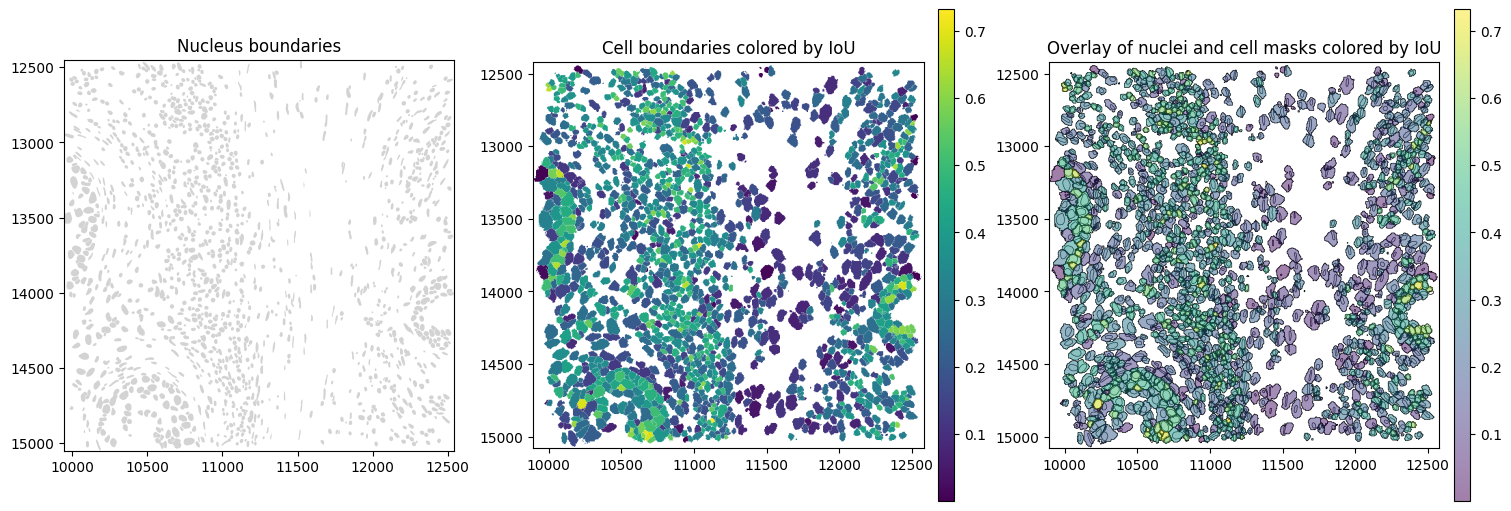

In [8]:
axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)[1].flatten()

# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

# plot
sdata_plot.pl.render_shapes("nucleus_boundaries").pl.show(
    ax=axes[0], title="Nucleus boundaries", coordinate_systems="global"
)

sdata_plot.pl.render_shapes("cell_boundaries", color="IoU").pl.show(
    ax=axes[1], title="Cell boundaries colored by IoU", coordinate_systems="global"
)

sdata_plot.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="IoU",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=axes[2], title="Overlay of nuclei and cell masks colored by IoU", colorbar=True)

The histogram of IoU distribution (below) shows a median IoU is at 0.55, i.e. 50% overlap. 

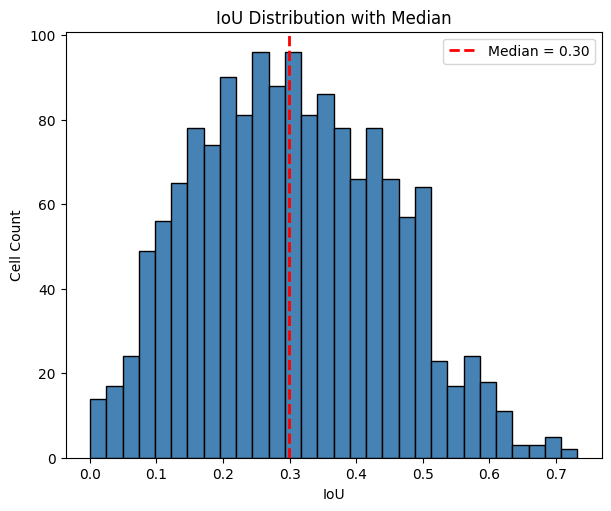

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare IoU values
ious = sdata["table"].obs["IoU"].dropna()
median_iou = np.median(ious)

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(ious, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_iou,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_iou:.2f}",
)

# Decorate
ax.set_title("IoU Distribution with Median")
ax.set_xlabel("IoU")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

## Expression correlation between cell and nucleus

Expression correlation between a cell and the "most-overlapping" nucleus can be computed using `compute_cell_nuc_correlation`. It is applicable only when nuclear masks are available. This function will internally compute `IoU` using `compute_cell_nuc_ious` unless already present in the `spatialdata`object. Currently only `pearson`correlation is supported. More options will be added later. 

In [10]:
start = time.time()
corr_df = st.rc.compute_cell_nuc_correlation(metric="cosine_sim")
end = time.time()

print(f"Elapsed time without computing IoU: {end - start:.2f} seconds")

Elapsed time without computing IoU: 11.53 seconds


In [11]:
corr_df

,cell,best_nuc_id,IoU,corr_nc_cell
0,70066.0,78094.0,0.372469,NaN
1,70067.0,NaN,NaN,NaN
2,70069.0,78081.0,0.621191,0.576391
3,70070.0,78084.0,0.357129,0.671159
4,70071.0,78083.0,0.662761,0.648800
...,...,...,...,...
1528,76434.0,94082.0,0.601019,0.873979
1529,76435.0,94078.0,0.275061,0.794473
1530,76436.0,94094.0,0.356451,0.616600
1531,76439.0,94091.0,0.306790,0.863939


In [61]:
sdata["table"].obs.sort_values("IoU")

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,corr_center_border,corr_border_ncv,corr_ncv_vs_center,corr_nc_cell,best_nuc_id,IoU,correlation_parts,focal_cell
70082,70082,77196,2169.410156,2651.197266,0.301136,4,55.00,318.0,1.0,cell_boundaries,NaN,NaN,NaN,0.294021,77194.0,0.000199,NaN,True
75281,75281,76684,2325.490967,3191.609375,0.394643,5,35.00,242.0,1.0,cell_boundaries,NaN,NaN,NaN,NaN,76682.0,0.001249,NaN,False
70129,70129,77958,2114.024658,2803.340820,0.378102,0,241.75,668.0,1.0,cell_boundaries,NaN,NaN,NaN,0.769131,77960.0,0.002710,NaN,False
72729,72729,94562,2660.090332,2835.238281,0.332983,3,29.75,238.0,1.0,cell_boundaries,NaN,NaN,NaN,NaN,94557.0,0.002849,NaN,False
72844,72844,94721,2663.235840,2952.622314,0.356061,6,82.50,378.0,1.0,cell_boundaries,NaN,NaN,NaN,0.656457,94692.0,0.004806,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75514,75514,95388,2518.449219,3192.875244,0.327290,5,65.50,326.0,1.0,cell_boundaries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
75524,75524,95382,2540.339844,3191.001953,0.335526,7,38.00,238.0,1.0,cell_boundaries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
76397,76397,95381,2573.933594,3190.499268,0.354661,3,73.75,350.0,1.0,cell_boundaries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
76401,76401,95385,2589.352539,3193.615967,0.395833,7,33.00,236.0,1.0,cell_boundaries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [41]:
cid = 70505

In [7]:
sdata["table"].obs[sdata["table"].obs["cell"] == cid]

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,best_nuc_id,IoU,correlation_parts
70505,70505,79051,2116.910889,2947.317383,0.361919,6,172.0,562.0,1.0,cell_boundaries,79054.0,0.018926,0.572078


In [35]:
sdata["cell_boundaries"].loc[cid].geometry.centroid.x

2117.06265063996

In [ ]:

sdata["cell_boundaries"].loc[cid].geometry.centroid.y

2946.431635430519

In [9]:
nid = sdata["table"].obs.loc[sdata["table"].obs["cell"] == cid, "best_nuc_id"]
x0= sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x*(1/0.2125)
y0= sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y*(1/0.2125)

In [10]:
sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x

cell_id
79054    2128.869268
dtype: float64

In [11]:
tx = sdata["transcripts"].compute()

In [15]:
tx.loc[tx["assignment"]==cid, :]

,transcript_id,repositioned_x,repositioned_y,repositioned_z,x,y,z,gene,assignment,background
5283763,281672545366185,2122.028809,2942.951172,0.186052,2125.028809,2945.951172,0.436052,TPD52,70505.0,False
5294269,281672545381740,2125.929932,2950.447998,0.123727,2126.929932,2950.447998,0.373727,CD9,70505.0,False
5294326,281672545381819,2122.862305,2948.702393,0.130605,2129.862305,2943.702393,0.130605,DSC2,70505.0,False
5391822,281672545518402,2123.530029,2949.254883,0.087048,2125.530029,2950.254883,0.087048,TCIM,70505.0,False
5391887,281672545518486,2123.535645,2952.943115,0.000000,2128.535645,2952.943115,0.000000,CTTN,70505.0,False
5421567,281672545556832,2124.321777,2945.722168,0.477278,2125.321777,2944.722168,0.477278,CDH1,70505.0,False
5450426,281672545595560,2125.205078,2951.131592,0.315274,2125.205078,2959.131592,0.315274,SLC5A6,70505.0,False
5474086,281672545628769,2124.278076,2952.315674,0.474640,2125.278076,2952.315674,0.474640,EPCAM,70505.0,False
5558315,281672545745539,2118.273193,2939.560303,0.122452,2126.273193,2936.560303,0.372452,TACSTD2,70505.0,False
5572356,281672545765320,2125.314697,2952.885254,0.232227,2125.314697,2952.885254,0.482227,SERPINA3,70505.0,False


In [12]:
tx.loc[tx["assignment"]==cid, "gene"].value_counts()

gene
KRT8        2
DSC2        2
EPCAM       2
TCIM        2
SLC5A6      2
           ..
CD79B       0
PDCD1LG2    0
APOBEC3A    0
BANK1       0
ADAM9       0
Name: count, Length: 480, dtype: int64

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


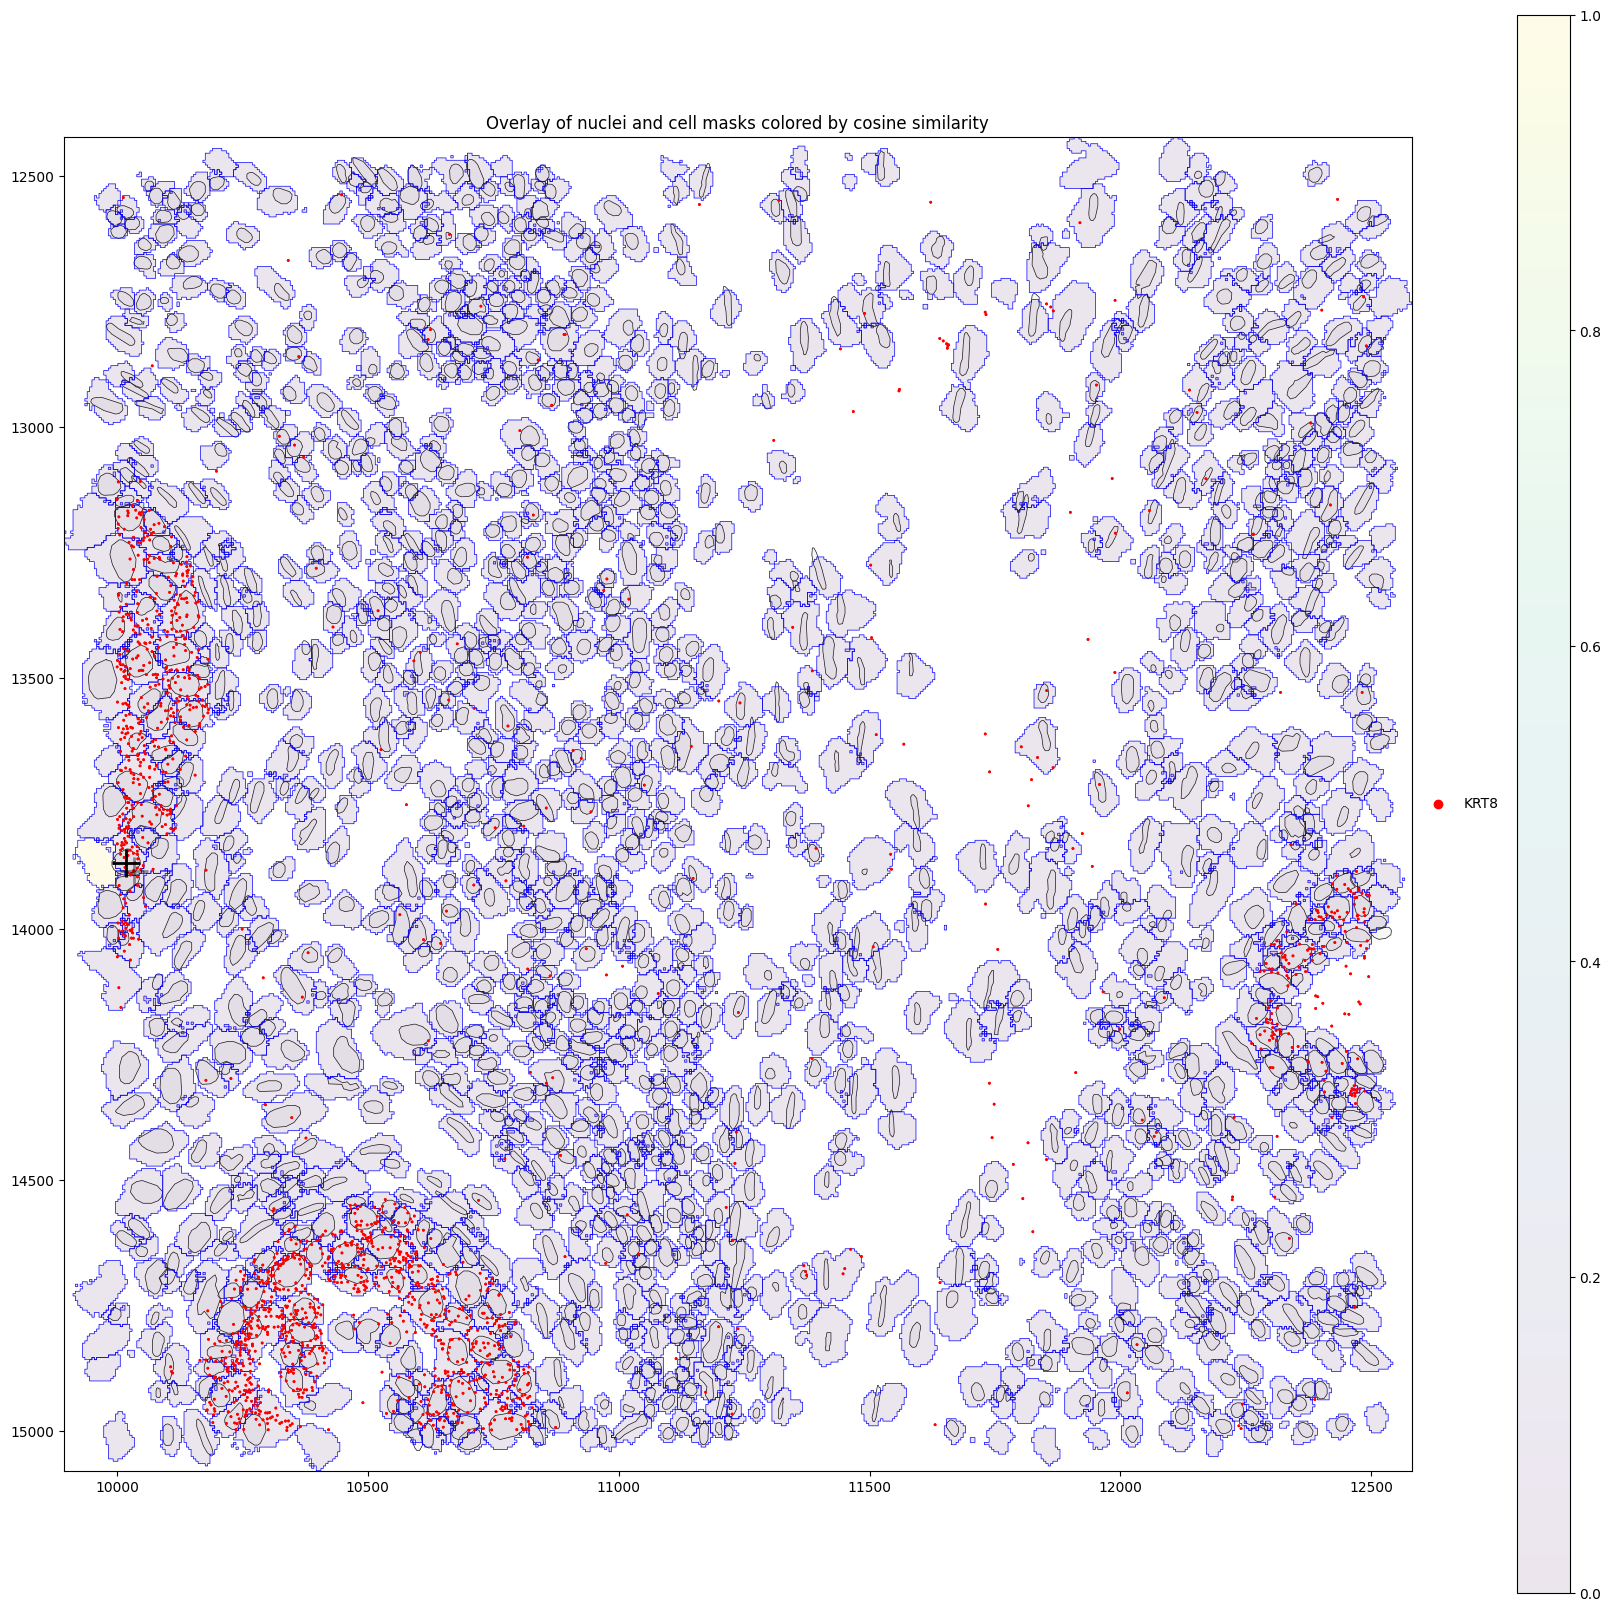

In [ ]:
axes = plt.subplots(1, 1, figsize=(16, 16), constrained_layout=True)[1]
sdata["table"].obs["focal_cell"] = sdata["table"].obs["cell"] == cid

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="focal_cell",
    #cmap="viridis",
    fill_alpha=0.1,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="blue",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["KRT8"],
    palette=["red"],
).pl.show(
    ax=axes,
    title="Overlay of nuclei and cell masks colored by cosine similarity",
    colorbar=True,
    figsize=(16, 16),
)

axes.scatter([x0], [y0], marker="+", s=400, c="black", linewidths=2, zorder=10)
axes.scatter([2117.06265063996/0.2125], [2950.3594/0.2125], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)

In [47]:
trans = sdata.points["transcripts"].compute()   # pandas DataFrame
trans["focal_cell"] = "other_cells"
trans.loc[trans["assignment"] == cid, "focal_cell"] = "focal_cell"
trans["focal_cell"] = trans["focal_cell"].astype("category")
trans = trans.drop(columns=["x", "y", "z"])
trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})

# write back if you want it in sdata
sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
T = sd.transformations.get_transformation(sdata.points["transcripts"])
sd.transformations.set_transformation(sdata.points["transcripts_2"], T)

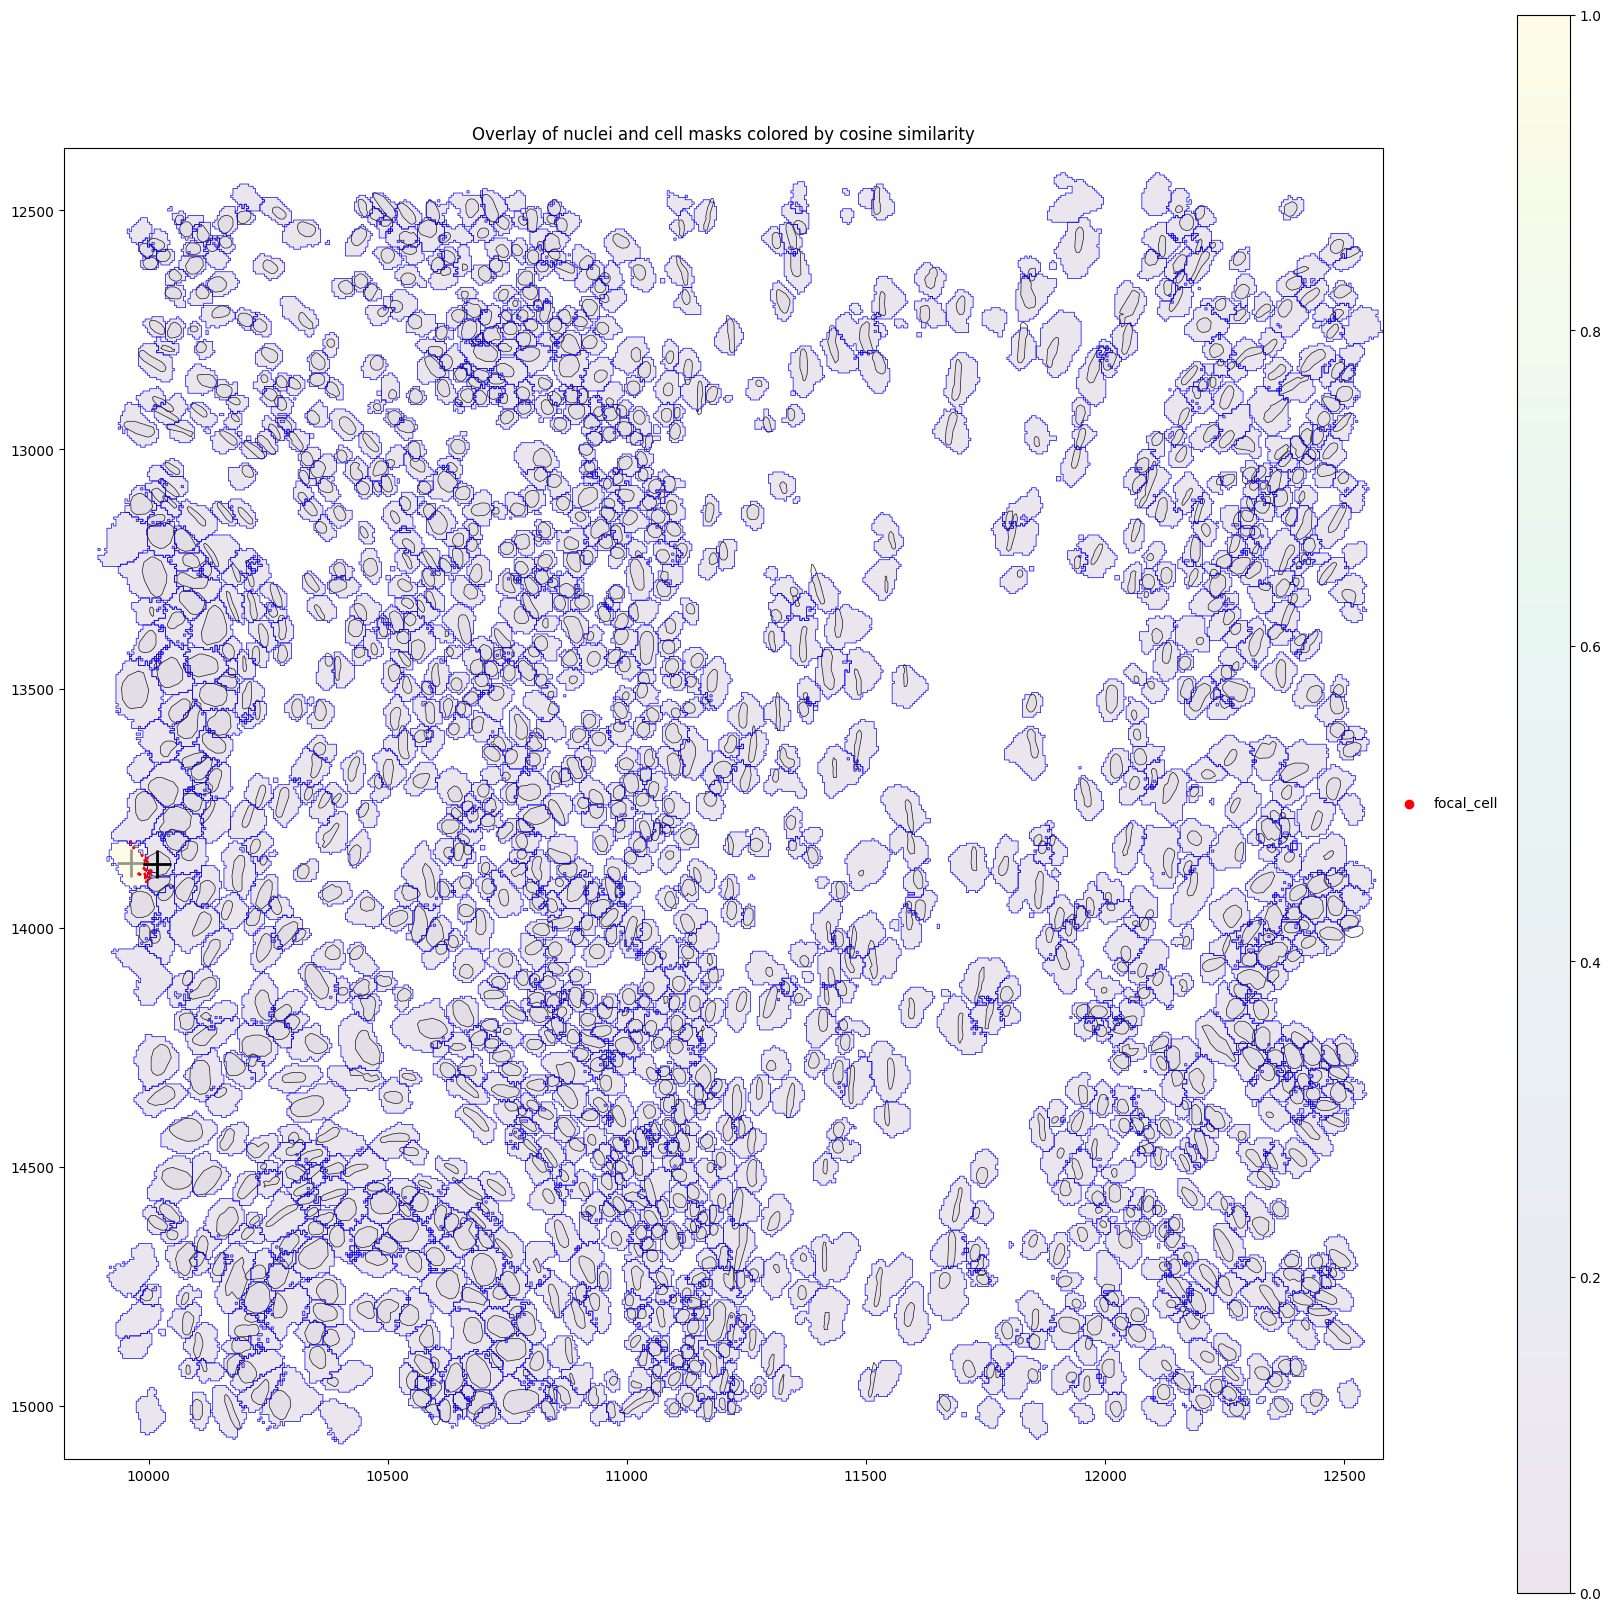

In [48]:
axes = plt.subplots(1, 1, figsize=(16, 16), constrained_layout=True)[1]
sdata["table"].obs["focal_cell"] = sdata["table"].obs["cell"] == cid

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="focal_cell",
    #cmap="viridis",
    fill_alpha=0.1,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="blue",
).pl.render_points(
    "transcripts_2",
    color="focal_cell",
    groups=["focal_cell"],
    palette=["red"],
).pl.show(
    ax=axes,
    title="Overlay of nuclei and cell masks colored by cosine similarity",
    colorbar=True,
    figsize=(16, 16),
)

axes.scatter([x0], [y0], marker="+", s=400, c="black", linewidths=2, zorder=10)
axes.scatter([2117.06265063996/0.2125], [2946.431635430519/0.2125], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)

The histogram below shows the distribution of cosine similarity values across cells. It is right-skewed, with a median of 0.76. This provides intuition about possible spatial spillover: cells may be contaminated by neighboring cells, assuming that nuclei capture expression with less contamination due to their smaller radius.

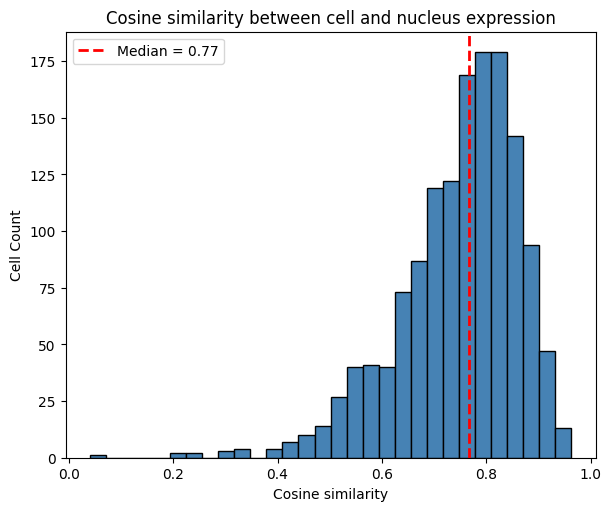

In [12]:
# Prepare corr values
obs = sdata["table"].obs
corr = obs["corr_nc_cell"].dropna()
median_corr = np.median(corr)

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(corr, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_corr,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_corr:.2f}",
)

# Decorate
ax.set_title("Cosine similarity between cell and nucleus expression")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The calculated R2 (coefficient of determination) is 0.369 indicating that correlation between cell and nucleus increases with their IoU. 

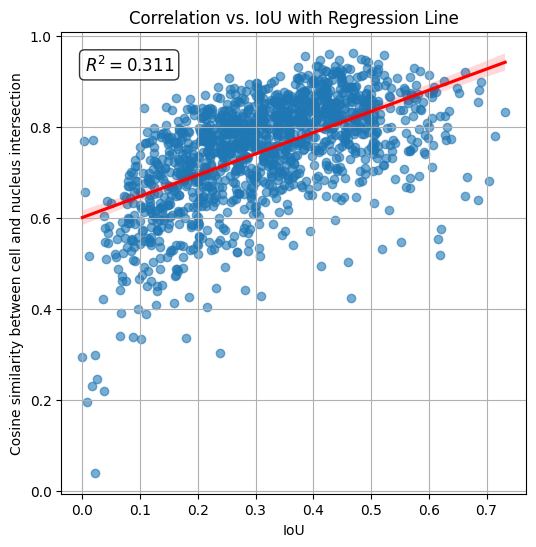

In [13]:
import seaborn as sns
from scipy.stats import linregress

# Extract the relevant columns, excluding NaNs
df = obs[["IoU", "corr_nc_cell"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["IoU"], df["corr_nc_cell"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="IoU",
    y="corr_nc_cell",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("IoU")
ax.set_ylabel("Cosine similarity between cell and nucleus intersection")
ax.set_title("Correlation vs. IoU with Regression Line")
ax.grid(True)

plt.show()

The spatial plot below overlays nucleus boundaries, cell masks colored by Pearson correlation, and transcripts. Cells whose transcripts are distributed across the nucleus region tend to have higher correlation with the nucleus, while cells whose transcripts are localized outside the nuclear region—potentially due to spillover from neighboring cells—tend to exhibit lower correlation.

In [14]:
# filter out entries with NaN correlation for plotting
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][
    (sdata_plot["table"].obs["corr_nc_cell"].notna() & sdata_plot["table"].obs["IoU"].notna())
]

/tmp/ipykernel_1199529/595549481.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


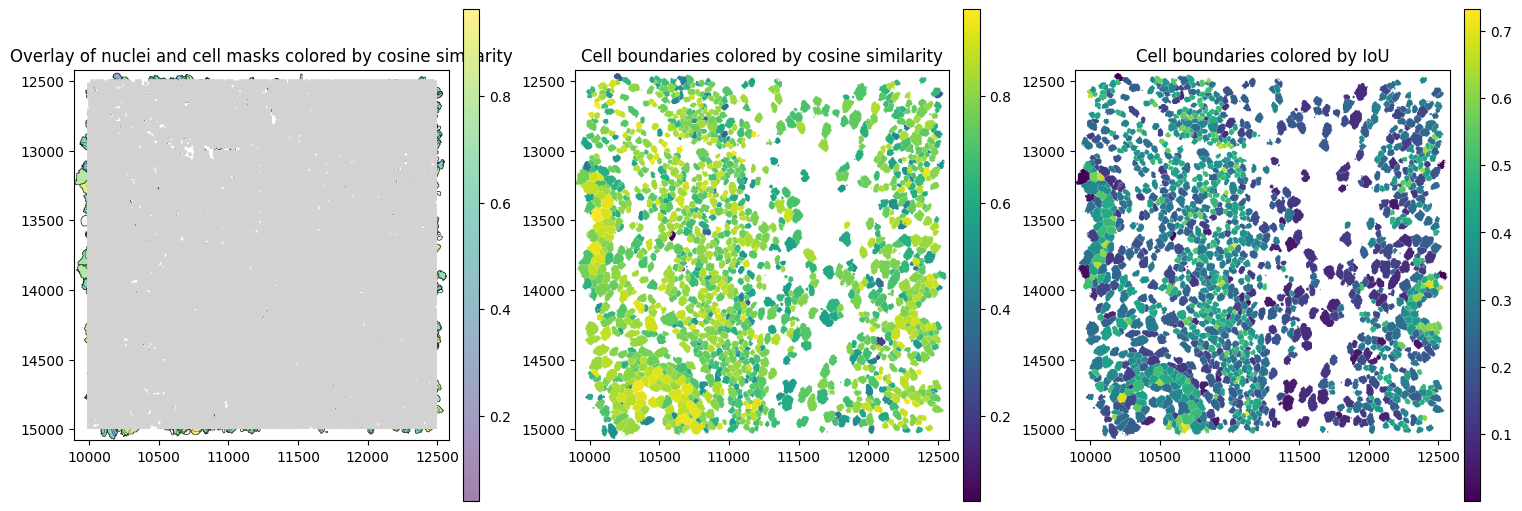

In [15]:
# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)[1].flatten()

sdata_plot.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_nc_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2", "CD44", "PTPRC"],
    palette=["red", "red", "red"],
).pl.show(
    ax=axes[0],
    title="Overlay of nuclei and cell masks colored by cosine similarity",
    colorbar=True,
    figsize=(6, 6),
)


sdata_plot.pl.render_shapes("cell_boundaries", color="corr_nc_cell").pl.show(
    ax=axes[1], title="Cell boundaries colored by cosine similarity", coordinate_systems="global"
)

sdata_plot.pl.render_shapes("cell_boundaries", color="IoU").pl.show(
    ax=axes[2], title="Cell boundaries colored by IoU", coordinate_systems="global"
)

## Correlation between Intersection and Remainder Parts of the Cell

The function `compute_correlation_between_parts()` computes the cosine similarity between the spatial transcript feature counts within the intersection of a cell and its matched nucleus, and the remainder of the cell. It is applicable only when nuclear masks are available. It returns `NaN` when the regions have no overlapping transcripts or lack sufficient variability. A low correlation may indicate that the cell boundary extension captures neighborhood or ambient signal rather than true intracellular expression—a concern similarly highlighted by segmentation benchmarks such as [Baysor](https://www.nature.com/articles/s41587-021-01044-w). This is based on the assumption that transcripts are homogeneously distributed within the cell and not localized in specific subcellular regions. 

In [5]:
#start = time.time()
corr_parts_df = st.rc.compute_correlation_between_parts(metric="cosine_sim")
end = time.time()

print(f"Elapsed time without computing IoU: {end - start:.2f} seconds")

Processing IoU between cells and nuclei: 100%|██████████| 1533/1533 [00:05<00:00, 277.71it/s]


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


NameError: name 'time' is not defined

In [17]:
corr_parts_df

,cell,best_nuc_id,IoU,correlation_parts
0,70066,78094.0,0.372469,NaN
1,70067,NaN,NaN,NaN
2,70069,78081.0,0.621191,0.604378
3,70070,78084.0,0.357129,0.556622
4,70071,78083.0,0.662761,0.332190
...,...,...,...,...
1528,76434,94082.0,0.601019,0.579845
1529,76435,94078.0,0.275061,0.539851
1530,76436,94094.0,0.356451,0.199518
1531,76439,94091.0,0.306790,0.510341


The histogram below shows that the cosine similarity between the intersection and remainder region of the cell is 0.08. 

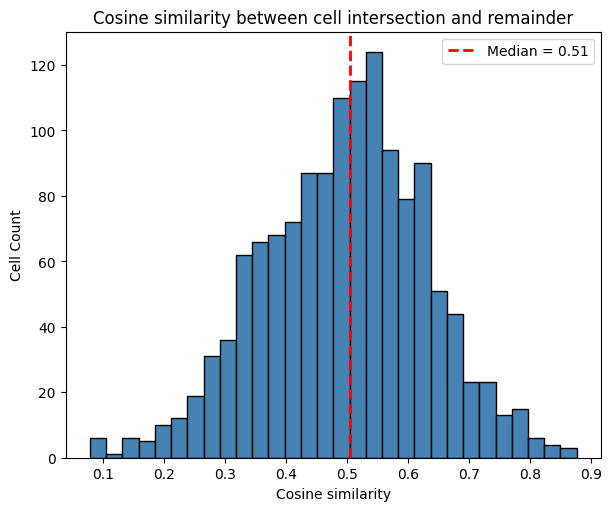

In [18]:
obs = sdata["table"].obs
# Prepare corr_parts values
corr = obs["correlation_parts"].dropna()
median_corr_parts = corr.median()

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(corr, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_corr_parts,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_corr_parts:.2f}",
)

# Decorate
ax.set_title("Cosine similarity between cell intersection and remainder")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The scatter plot below visualizes the cosine similarity between transcript counts in the intersection and remainder of each cell, plotted against the Intersection over Union (IoU) with the nucleus. The calculated R2 value is 0.000, indicating that `correlation_parts` is independent of `IoU`.

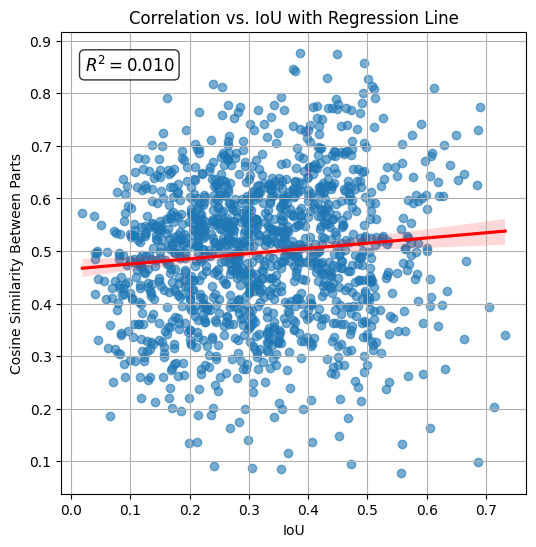

In [19]:
import seaborn as sns

# Extract the relevant columns, excluding NaNs
df = obs[["IoU", "correlation_parts"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["IoU"], df["correlation_parts"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="IoU",
    y="correlation_parts",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("IoU")
ax.set_ylabel("Cosine Similarity Between Parts")
ax.set_title("Correlation vs. IoU with Regression Line")
ax.grid(True)

plt.show()

Because `spatialdata-plot` plots all boundaries in grey, if there are NaN values in the annotation (describe [before](https://github.com/scverse/spatialdata-plot/pull/87)), we will copy the `correlation_parts` column and set `NaN`values to `0.0`just for plotting. We will try to solve this issue later. 

In [20]:
# filter out entries with NaN correlation for plotting
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][
    (sdata_plot["table"].obs["corr_nc_cell"].notna() & sdata_plot["table"].obs["correlation_parts"].notna())
]

The spatial plots below shows the spatial distribution of computed correlations. The Pearson correlation between parts can be a measure of how much neighboring signal is captured. 

/tmp/ipykernel_1199529/3823815026.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


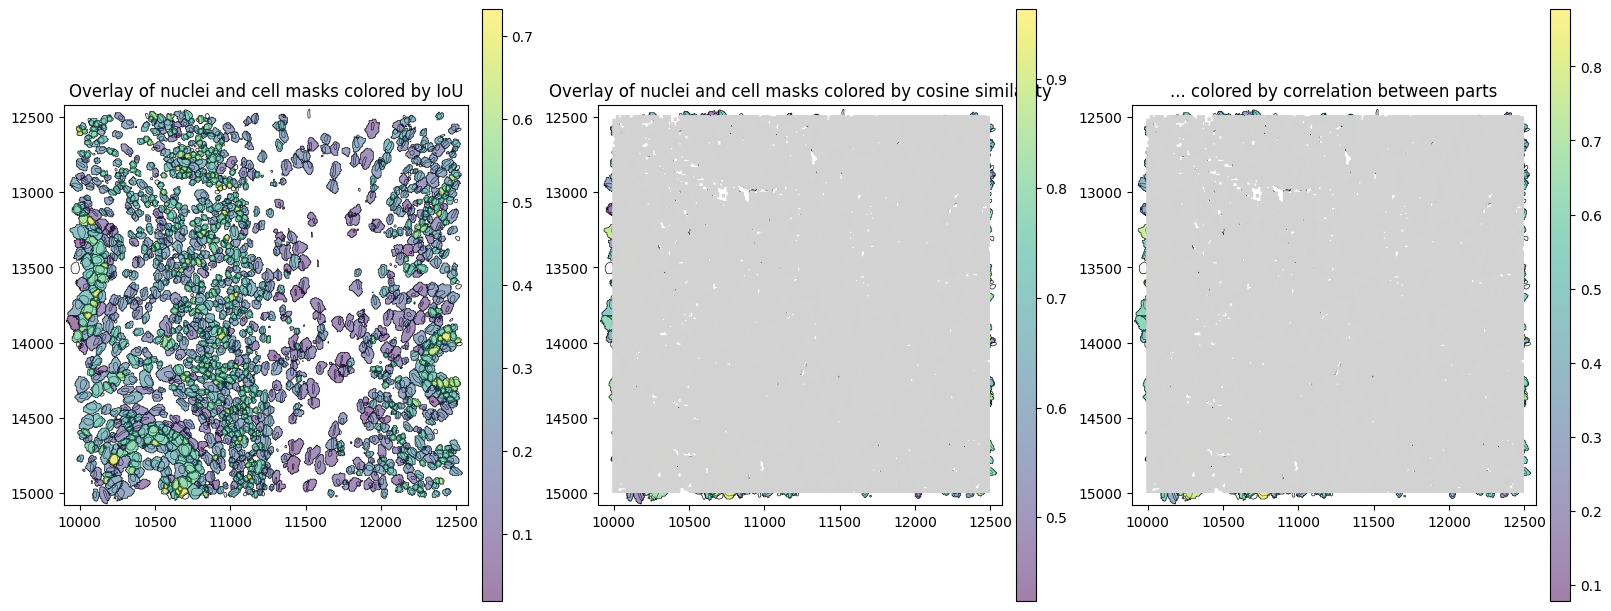

In [21]:
# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)[1].flatten()

sdata_plot.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="IoU",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[0],
    title="Overlay of nuclei and cell masks colored by IoU",
    colorbar=True,
    figsize=(6, 6),
)

sdata_plot.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_nc_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups="ERBB2",
    palette="red",
).pl.show(
    ax=axes[1],
    title="Overlay of nuclei and cell masks colored by cosine similarity",
    colorbar=True,
    figsize=(6, 6),
)

sdata_plot.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="correlation_parts",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups="ERBB2",
    palette="red",
).pl.show(
    ax=axes[2],
    title="... colored by correlation between parts",
    colorbar=True,
    figsize=(6, 6),
)

## Correlation cell border with its center and its neigbhorhood
The function `compute_correlation_between_parts()` computes the cosine similarity between (1) the cell border and an eroded interior and (2) the cell border and the immediate neighborhood.     Specifically, the function:
1. Erodes each cell polygon to obtain a center region.
2. Defines the border region as the set difference between the full cell
   and its eroded center.
3. Computes gene expression profiles for center and border.
4. Computes the correlation between center and border expression.
5. Computes the correlation between border expression and the
   NCV expression profile of the same cell.
6. The ratio of the latter two

In [22]:
start = time.time()
corr_center_border_ncv_df = st.rc.compute_center_border_ncv_correlation()
end = time.time()

print(f"Elapsed time without computing IoU: {end - start:.2f} seconds")

/g/huber/users/lazic/src/SegTraQ/src/segtraq/rc/utils.py:95: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = cells_gdf.geometry.area


/g/huber/users/lazic/src/SegTraQ/src/segtraq/rc/utils.py:328: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = cells_gdf.geometry.centroid
/g/huber/users/lazic/src/SegTraQ/src/segtraq/rc/utils.py:331: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = cells_gdf.geometry.area


Elapsed time without computing IoU: 24.05 seconds


In [23]:
corr_center_border_ncv_df

,region_id,corr_center_border,corr_border_ncv,corr_ncv_vs_center
0,70069,0.489025,0.276086,0.564564
1,70070,0.393539,0.178400,0.453322
2,70072,0.480105,0.481392,1.002680
3,70073,0.559856,0.380872,0.680304
4,70074,0.440363,0.355462,0.807202
...,...,...,...,...
1118,76431,0.419393,0.342724,0.817191
1119,76432,0.399035,0.229246,0.574499
1120,76433,0.387257,0.196884,0.508406
1121,76434,0.423582,0.165794,0.391409


The histogram below shows the distribution of the correlation between the cell center and border.

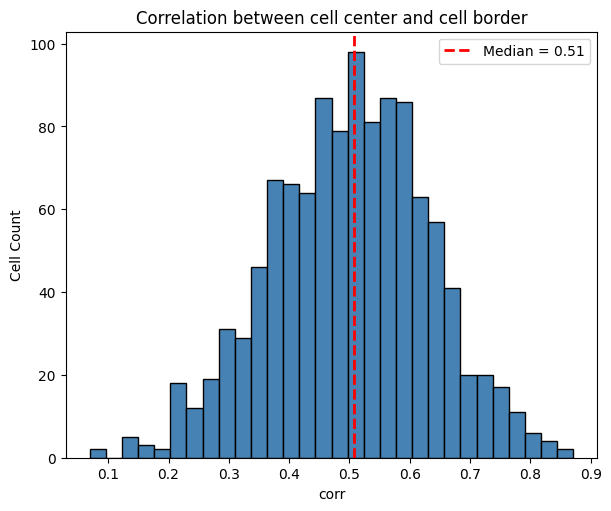

In [24]:
corr = sdata["table"].obs["corr_center_border"].dropna()
median_iou = np.median(corr)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.hist(corr, bins=30, color="steelblue", edgecolor="black")

ax.axvline(
    median_iou,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_iou:.2f}",
)

ax.set_title("Correlation between cell center and cell border")
ax.set_xlabel("corr")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The histogram below shows the distribution of the correlation between the cell border and its neigbhorhood (with a distance of twice cell radius from its centroid). As expected, the correlation to the cell center is higher than to the cell neighborhood. This will differ depending on whether the cell is located within a homogeneous or a heterogeneous neighborhood.

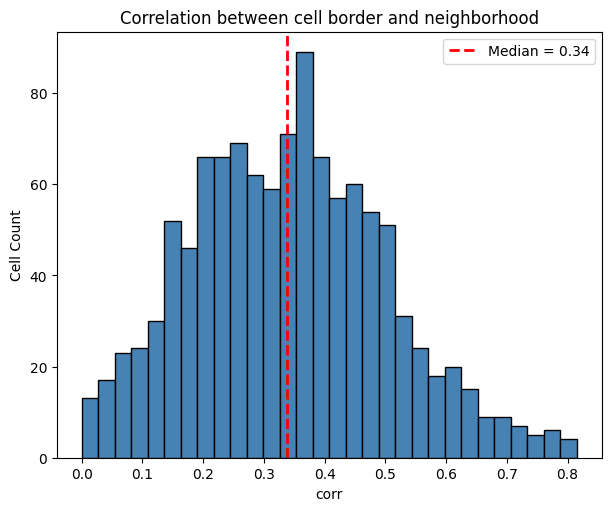

In [25]:
corr = sdata["table"].obs["corr_border_ncv"].dropna()
median_iou = np.median(corr)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.hist(corr, bins=30, color="steelblue", edgecolor="black")

ax.axvline(
    median_iou,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_iou:.2f}",
)

ax.set_title("Correlation between cell border and neighborhood")
ax.set_xlabel("corr")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

The scatter plot below visualizes the cosine similarity between the cell border and its neigbhorhood plotted against the cosine simiarity between the cell border and cell center. The calculated R2 (coefficient of determination) value is 0.38. 

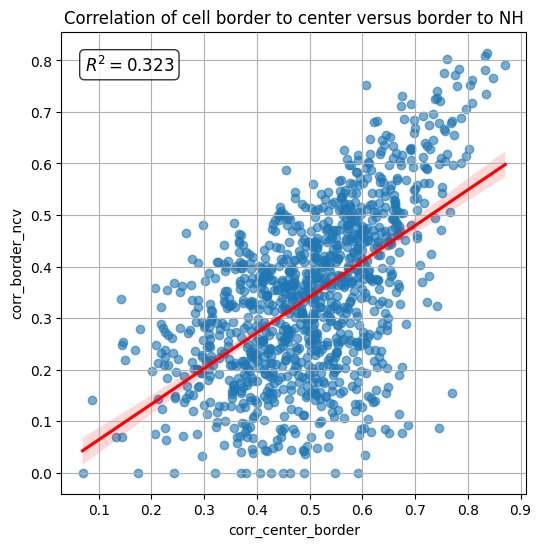

In [26]:
obs = sdata["table"].obs
# Extract the relevant columns, excluding NaNs
df = obs[["corr_center_border", "corr_border_ncv"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["corr_center_border"], df["corr_border_ncv"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="corr_center_border",
    y="corr_border_ncv",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("corr_center_border")
ax.set_ylabel("corr_border_ncv")
ax.set_title("Correlation of cell border to center versus border to NH")
ax.grid(True)

plt.show()

The spatial plots below shows the spatial distribution of computed correlations. 

In [27]:
# filter out entries with NaN correlation for plotting
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][
    (sdata_plot["table"].obs["corr_center_border"].notna() & sdata_plot["table"].obs["corr_border_ncv"].notna())
]

/tmp/ipykernel_1199529/4198321451.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


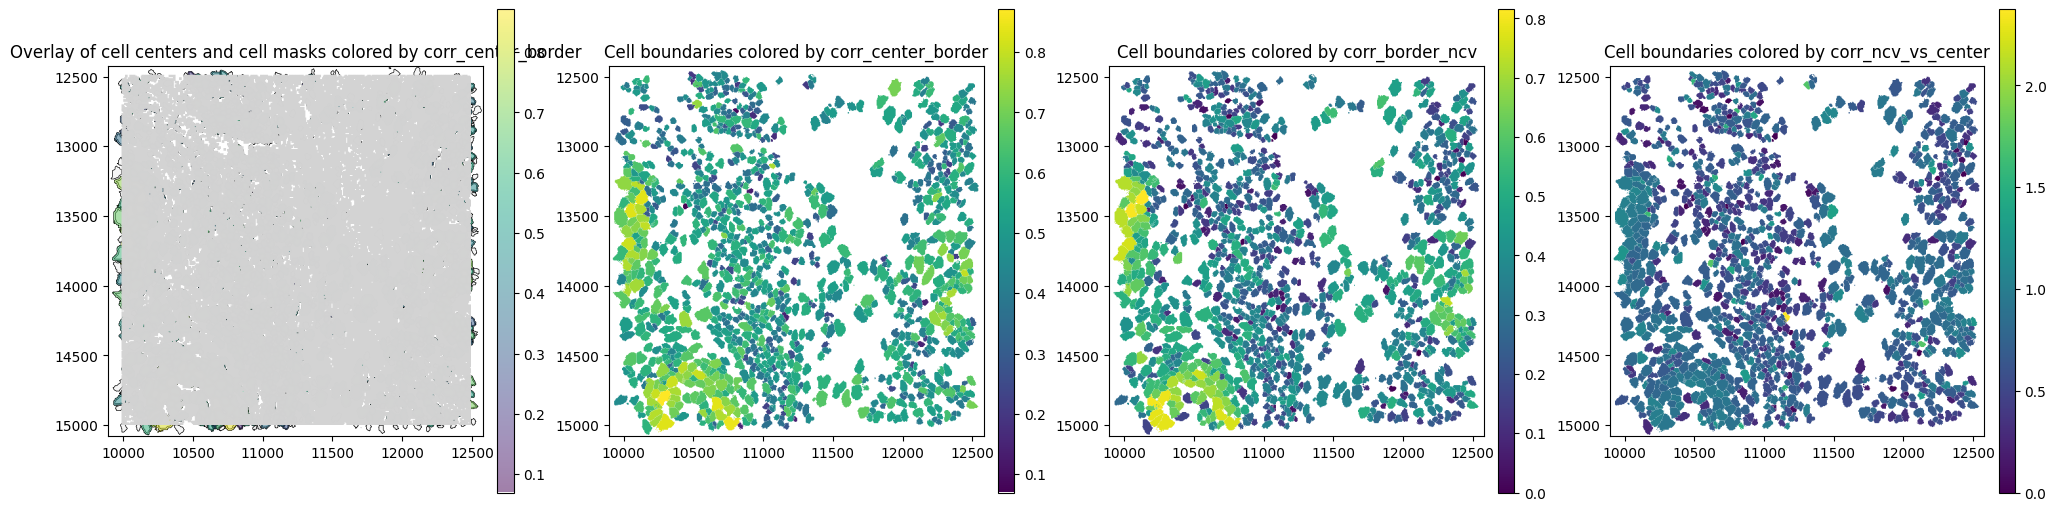

In [28]:
# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)[1].flatten()

sdata_plot.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_center_border",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2", "CD44", "PTPRC"],
    palette=["red", "red", "red"],
).pl.show(
    ax=axes[0],
    title="Overlay of cell centers and cell masks colored by corr_center_border",
    colorbar=True,
    figsize=(6, 6),
)


sdata_plot.pl.render_shapes("cell_boundaries", color="corr_center_border").pl.show(
    ax=axes[1], title="Cell boundaries colored by corr_center_border", coordinate_systems="global"
)

sdata_plot.pl.render_shapes("cell_boundaries", color="corr_border_ncv").pl.show(
    ax=axes[2], title="Cell boundaries colored by corr_border_ncv", coordinate_systems="global"
)

sdata_plot.pl.render_shapes("cell_boundaries", color="corr_ncv_vs_center").pl.show(
    ax=axes[3], title="Cell boundaries colored by corr_ncv_vs_center", coordinate_systems="global"
)

All of the metrics are also stored in the spatialdata object.

In [29]:
sdata.tables["table"]

AnnData object with n_obs × n_vars = 1533 × 480
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'corr_nc_cell', 'best_nuc_id', 'IoU', 'correlation_parts', 'corr_center_border', 'corr_border_ncv', 'corr_ncv_vs_center'
    var: 'gene', 'total_count', 'lambda_bg_0', 'lambda_bg_1', 'lambda_bg_2', 'lambda_bg_3'
    uns: 'spatialdata_attrs', 'proseg_run'
    obsm: 'spatial'
    obsp: 'transition_counts'

Alternatively, all `nc` metrics can be computed in one run via `run_region_correlation`.

In [30]:
st.run_region_correlation()
sdata.tables["table"].obs.head()

Processing IoU between cells and nuclei: 100%|██████████| 1533/1533 [00:02<00:00, 642.19it/s]


KeyboardInterrupt: 